In [7]:
from mor_Pauli import *

from time import time

from scipy.linalg import pinvh
from scipy.stats import unitary_group, gaussian_kde
from scipy import sparse

from time import sleep
from multiprocessing import Pool

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('text', usetex=True)

In [8]:
def fkron(A, B):
    """ A faster kronecker product taken from https://stackoverflow.com/a/56067827 """
    s = len(A)*len(B)
    return (A[:, None, :, None]*B[None, :, None, :]).reshape(s, s)

### Functions

In [9]:
def swap_matrix(n_qudits, q1, q2, dim=2):
    p1, p2 = sorted([q1, q2])
    SW = zeros([dim**n_qudits, dim**n_qudits])
    SW_ph = zeros([dim, dim])
    for i in range(dim):
        for j in range(dim):
            SW_ph[i, j] = 1
            SW_ij = array(SW_ph)
            SW_ph[i, j] = 0
            SW_ph[j, i] = 1
            SW_ji = array(SW_ph)
            SW_ph[j, i] = 0
            op = reduce(kron, [eye(dim**p1), SW_ij, eye(dim**(p2 - p1 - 1)), SW_ji, eye(dim**(n_qudits - p2 - 1))])
            SW += op    
    return SW

def swap_matrix_sparse(n_qudits, q1, q2, dim=2):
    p1, p2 = sorted([q1, q2])
    SW = sparse.csr_array(zeros([dim**n_qudits, dim**n_qudits]))
    SW_ph = zeros([dim, dim])
    for i in range(dim):
        for j in range(dim):
            SW_ph[i, j] = 1
            SW_ij = array(SW_ph)
            SW_ph[i, j] = 0
            SW_ph[j, i] = 1
            SW_ji = array(SW_ph)
            SW_ph[j, i] = 0
            op = reduce(sparse.kron, [sparse.eye(dim**p1), SW_ij, sparse.eye(dim**(p2 - p1 - 1)), SW_ji, sparse.eye(dim**(n_qudits - p2 - 1))])
            SW += op    
    return SW

In [10]:
def train_obs_L(labels, ansatz, L, n_copies=1, method="Newton-CG", x0=None, options={}):

    n_pars = len(ansatz)
    n_train = len(labels)

    ### precalcs ###
    L_T = L.T
    LL = L_T@L
    L_T_alpha = L_T@labels
    
    fval_cont = []
    def fun(x):
        expecs = x@L_T
        f = np.sum((expecs - labels)**2)
        fval_cont.append(f)
        return f

    def jac(x):
        return -2*L_T_alpha + 2*LL@x

    def hess(x):
        return 2*LL
    
    time_loc = time()
    
    def callback(x):
        print("\t\t\tIteration: %d | Cost: %.8f | Time passed: %d s" %(len(fval_cont), fval_cont[-1], time() - time_loc), end="\r")
        return None
    
    if method in ["Nelder-Mead", "L-BFGS-B", "SLSQP", "TNC", "Powell", "COBYLA", "COBYQA"]:
        bounds = [(-100, 100)]*n_pars # some arbitrary values 
    else:
        bounds = None
    if x0 is None:
        x0 = normal(0, 1e-5, n_pars)
    
    optimization_result = minimize(fun=fun, jac=jac, hess=hess, x0=x0, bounds=bounds, method=method, callback=callback, options=options) # "maxiter": int(1e10)

    return optimization_result.x

In [11]:
from sympy.combinatorics import Permutation

def string_to_matrix(operator_string):
    operator = []
    for char in operator_string:
        if char == '_':
            operator.append(I)
        elif char == 'X':
            operator.append(X)
        elif char == 'Y':
            operator.append(Y)
        elif char == 'Z':
            operator.append(Z)
    return reduce(kron, operator)

def hermitian_mat_to_dict(hermitian, pauli_basis=None, tol=1e-5):
    """ With pre-computed pauli_basis, should be not very slow and save memory, more or less. """        
    n = (len(hermitian) - 1).bit_length() # fast log2
    pauli_strings = product(['_', 'X', 'Y', 'Z'], repeat=n)
    if pauli_basis is None: # if not pre-computed
        pauli_basis = (reduce(kron, string) for string in product([I, X, Y, Z], repeat=n))
    hermitian_dict = {}
    for string, operator in zip(pauli_strings, pauli_basis):
        expec = trace(hermitian@operator).real
        if abs(expec) >= tol:
            label = ''.join(string)
            hermitian_dict[label] = expec / 2**n
    return hermitian_dict

def hermitian_dict_to_mat(hermitian_dict, pauli_basis=None, tol=1e-5):
    n = len(list(hermitian_dict.keys())[0])
    hermitian_mat = zeros([2**n, 2**n], dtype=complex)
    for string, coef in hermitian_dict.items():
        hermitian_mat += coef*string_to_matrix(string)
    return hermitian_mat

In [12]:
def compute_L(dms, ansatz, n_copies=1):
    n_train = len(dms)
    n_pars = len(ansatz)
    L = zeros((n_train, n_pars))
    time_start = time()
    for i in range(n_train):
        print("Computing L: i=%d | time passed: %.2f s" %(i, time() - time_start), end="\r")
        dm_c = reduce(fkron, [dms[i]]*n_copies)
        for j in range(n_pars):
            op_loc = dm_c@ansatz[j]
            L[i][j] = trace(op_loc).real
    time_finish = time() - time_start
    print("Computing L: finished in %.2f s" %time_finish, end="\r")
    return L

def compute_LS(dms, ansatz, n_copies=1):
    n_train = len(dms)
    n_pars = len(ansatz)
    L = zeros((n_train, n_pars))
    S = zeros((n_train, n_pars, n_pars))
    time_start = time()
    for i in range(n_train):
        print("Computing L and S: i=%d | time passed: %.2f s" %(i, time() - time_start), end="\r")
        dm_c = reduce(fkron, [dms[i]]*n_copies)
        for j in range(n_pars):
            op_loc = dm_c@ansatz[j]
            L[i][j] = trace(op_loc).real
            for k in range(n_pars):
                S[i][j][k] = trace(op_loc@ansatz[k]).real
    time_finish = time() - time_start
    print("Computing L and S: finished in %.2f s" %time_finish, end="\r")
    return L, S

In [13]:
def aux_info(dms, labels, pars, ansatz, n_copies=1):

    n_tot = int(log2(len(dms[0])))*n_copies
    n_labels = len(labels)

    H = zeros([2**n_tot, 2**n_tot], dtype=complex)
    for par, op in zip(pars, ansatz):
        H += par*op
    H_sq = H@H

    expecs = zeros(n_labels, dtype=float)
    disps = zeros(n_labels, dtype=float)
    for i in range(n_labels):
        print("i = %d" %i, end="\r")
        dm_c = reduce(fkron, [dms[i]]*n_copies)
        expecs[i] = trace(H@dm_c).real
        disps[i] = trace(H_sq@dm_c).real
    disps = disps - expecs**2
    
    return expecs, disps, H

### Loading the dataset

In [15]:
n_train = 100
file_name=f'overfitting_train_%i_in_4_cases.npz'%n_train
#dms_train, labels_train = gen_even_ent_data(n_train, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
#np.savez(file_name, dms_train=dms_train, labels_train=labels_train)
data=np.load(file_name)
dms_train_100=data["dms_train"]
labels_train_100=data["labels_train"]
purities_train_100 = [trace(dm@dm).real for dm in dms_train_100]

In [32]:
n_train = 1000
file_name=f'overfitting_train_%i_in_4_cases.npz'%n_train
#dms_train, labels_train = gen_even_ent_data(n_train, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
#np.savez(file_name, dms_train=dms_train, labels_train=labels_train)
data=np.load(file_name)
dms_train_1000=data["dms_train"]
labels_train_1000=data["labels_train"]
purities_train_1000 = [trace(dm@dm).real for dm in dms_train_1000]

In [16]:
n_inp = 2
n_test = 1000
mixed = True
marks = "negSq"
eps = 1e-3
#dms_test, labels_test = gen_even_ent_data(n_test, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
file_name="overfitting_test_1000_in_4_cases.npz"
#np.savez(file_name, dms_test=dms_test, labels_test=labels_test)
data=np.load(file_name)
dms_test=data["dms_test"]
labels_test=data["labels_test"]
purities_test = [trace(dm@dm).real for dm in dms_test]

### Lower copies

In [17]:
n_copies=3
n_tot = n_inp*n_copies

In [18]:
""" local neighbouring Paulies """

# lazy (and inefficient); if locality>2, *does* contain terms like AIBIIIII with A and B being Paulies
locality = 4
ansatz = []
ansatz_st = []
op_gen = product([I_sp, X_sp, Y_sp, Z_sp], repeat=locality)
st_gen = product(["_", "X", "Y", "Z"], repeat=locality)
c = 0
for line_op, line_st in zip(op_gen, st_gen):
    print(c, end="\r")
    st_base = "".join(line_st[::-1]) + "_"*(n_tot - locality)  # [::-1] is just for pretty printing
    op_base = list(line_op[::-1]) + [I_sp]*(n_tot - locality)
    for q in range(n_tot - 0):
        st = st_base[-q:] + st_base[:-q]
        if st not in ansatz_st:
            op = op_base[-q:] + op_base[:-q]
            ansatz_st.append(st)
            ansatz.append(reduce(sparse.kron, op))
    c += 1

ansatz_info = "%d-local_periodic_Paulies" %locality

n_pars = len(ansatz)
n_pars

# ansatz_st

1126

In [19]:
L = compute_L(dms_train_100, ansatz, n_copies=n_copies)

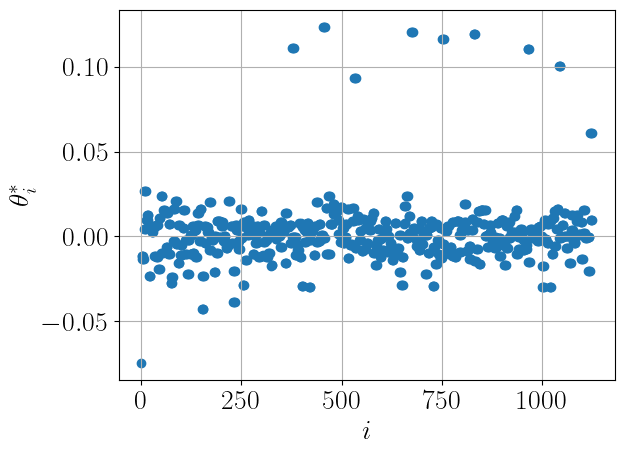

In [20]:
pars = train_obs_L(labels_train_100, ansatz, L, method="Newton-CG")
# pars = train_obs_L(labels_train_c, ansatz, L, method="BFGS")
# pars = lstsq(A, b)[0]

s = 0
f = n_pars
plt.scatter(arange(len(pars))[s:f], pars[s:f])
plt.xlabel(r"$i$")
plt.ylabel(r"$\theta_i^*$")
plt.grid()
plt.show()

In [25]:
labels_train_c = array(labels_train_100)
labels_test_c = array(labels_test)


Prediction finished in 0 s
n=2 | c=3
n_train: 100 | n_test: 1000
marks: negSq
4-local_periodic_Paulies | n_pars: 1126

MSE:            0.016608984989220667
Total variance: 0.6824780933986088


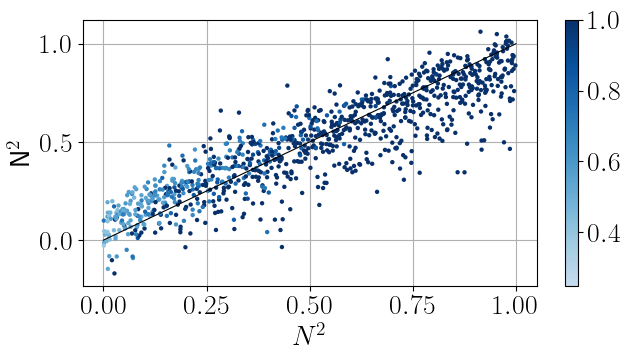

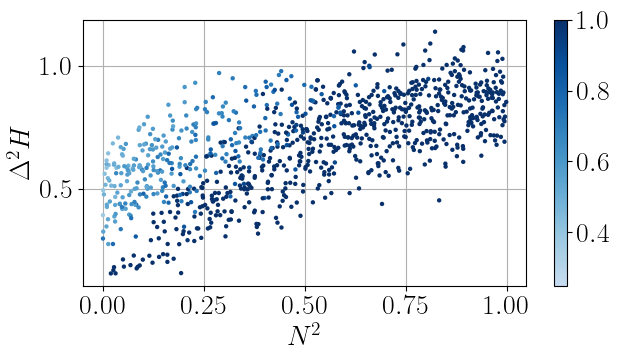

In [26]:
print()
time_start = time()
expecs_train, disps_train, H = aux_info(dms_train_100, labels_train_100, pars, ansatz, n_copies=n_copies)
expecs_test, disps_test, H = aux_info(dms_test, labels_test_c, pars, ansatz, n_copies=n_copies)
time_finish = time() - time_start
print("Prediction finished in %d s" %time_finish)


cmap_name = "Blues"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.25, 1., cmap.N))
cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

print("n=%d | c=%d" %(n_inp, n_copies))
print("n_train: %d | n_test: %d" %(n_train, n_test))
print("marks: %s" %marks)
print("%s | n_pars: %d" %(ansatz_info, n_pars))
# print(" n_pars: %d" %(n_pars))
print()
print("MSE:           ", sum((expecs_test - labels_test_c)**2)/n_test)
print("Total variance:", sum(disps_test)/n_test)

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
# plt.scatter(labels_train_c, expecs_train, color="tab:red", s=30, edgecolor='none', zorder=2) # , color="dodgerblue"
plt.scatter(labels_test_c, expecs_test, c=purities_test, cmap=cmap, s=10, edgecolor='none', zorder=2) # , color="dodgerblue"
plt.plot(linspace(0, 1), linspace(0, 1), linestyle="-", linewidth=0.8, color="black")
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\mathsf{N}^2$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
# plt.savefig(path + file_name + add_info + "-est.pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
# plt.scatter(labels_train_c, disps_train, color="tab:red", s=30, edgecolor='none', zorder=2, label="train")
plt.scatter(labels_test_c, disps_test, c=purities_test, cmap=cmap, s=10, edgecolor='none', zorder=2, label="test")
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\Delta^2 H$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
# plt.legend()
# plt.savefig(path + file_name + add_info + "-var.pdf", transparent=True, bbox_inches='tight')
plt.show()

### Training with Pauli locality=4, copies=4

In [27]:
n_copies=4
n_inp = 2
n_tot = n_inp*n_copies
n_train=1000
""" local neighbouring Paulies """

# lazy (and inefficient); if locality>2, *does* contain terms like AIBIIIII with A and B being Paulies
locality = 4
ansatz = []
ansatz_st = []
op_gen = product([I_sp, X_sp, Y_sp, Z_sp], repeat=locality)
st_gen = product(["_", "X", "Y", "Z"], repeat=locality)
c = 0
for line_op, line_st in zip(op_gen, st_gen):
    print(c, end="\r")
    st_base = "".join(line_st[::-1]) + "_"*(n_tot - locality)  # [::-1] is just for pretty printing
    op_base = list(line_op[::-1]) + [I_sp]*(n_tot - locality)
    for q in range(n_tot - 0):
        st = st_base[-q:] + st_base[:-q]
        if st not in ansatz_st:
            op = op_base[-q:] + op_base[:-q]
            ansatz_st.append(st)
            ansatz.append(reduce(sparse.kron, op))
    c += 1

ansatz_info = "%d-local_periodic_Paulies" %locality

n_pars = len(ansatz)
n_pars

# ansatz_st

1537

In [30]:
from paralellel_L import *

#### Training with 1000 states

In [33]:
# compute_L_parallel, it is pre-run, and took ~10000 seconds
# L_1000 = parallel_compute_L(dms_train_1000, ansatz, n_copies=n_copies, n_processes=None)

Completed in 10045.02s                            


In [51]:
n_train=1000
# file_name=f'overfitting_train_Pauli_%i_L.npz'%n_train
# np.savez(file_name, L=L_1000, dms_train=dms_train_1000, labels_train=labels_train_1000)
data=np.load(file_name)
L_1000=data["L"]
dms_train_1000=data["dms_train"]
labels_train_1000=data["labels_train"]
purities_train_1000 = [trace(dm@dm).real for dm in dms_train_1000]


In [35]:
# n_train=1000
# file_name=f'overfitting_train_Pauli_%i_L.npz'%n_train
# np.savez(file_name, L=L_1000, dms_train=dms_train_1000, labels_train=labels_train_1000)

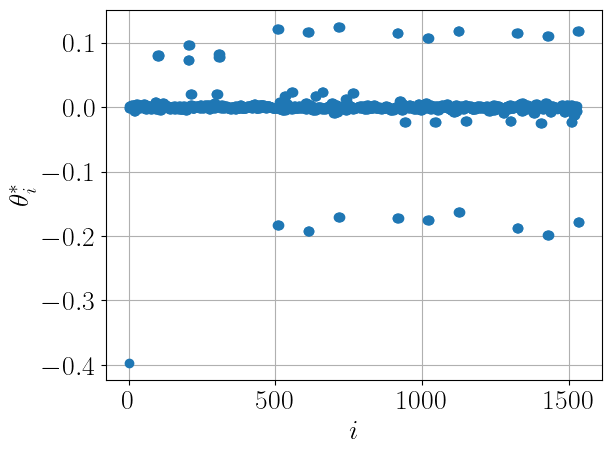

In [52]:
pars = train_obs_L(labels_train_1000, ansatz, L, method="Newton-CG")

s = 0
f = n_pars
plt.scatter(arange(len(pars))[s:f], pars[s:f])
plt.xlabel(r"$i$")
plt.ylabel(r"$\theta_i^*$")
plt.grid()
plt.show()


Prediction finished in 14 s
n=2 | c=4
n_train: 1000 | n_test: 1000
marks: negSq
4-local_periodic_Paulies | n_pars: 1537

MSE:            0.0005022205539632846
Total variance: 1.2324449097290129


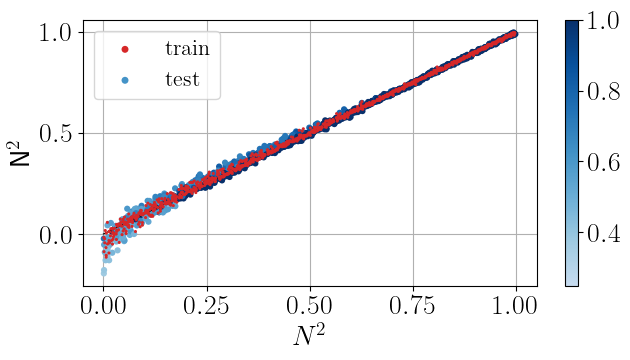

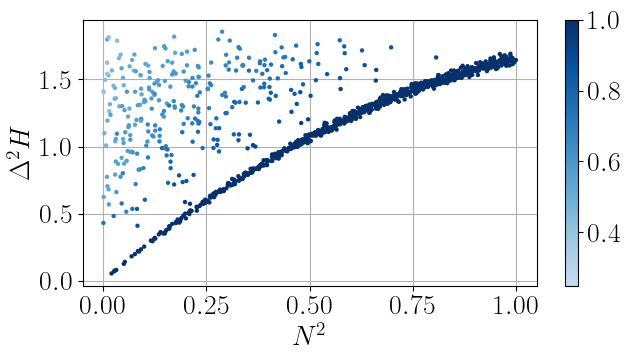

In [59]:
print()
time_start = time()
expecs_train, disps_train, H = aux_info(dms_train_1000, labels_train_1000, pars, ansatz, n_copies=n_copies)
expecs_test, disps_test, H = aux_info(dms_test, labels_test, pars, ansatz, n_copies=n_copies)
time_finish = time() - time_start
print("Prediction finished in %d s" %time_finish)


cmap_name = "Blues"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.25, 1., cmap.N))
cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

print("n=%d | c=%d" %(n_inp, n_copies))
print("n_train: %d | n_test: %d" %(n_train, n_test))
print("marks: %s" %marks)
print("%s | n_pars: %d" %(ansatz_info, n_pars))
# print(" n_pars: %d" %(n_pars))
print()
print("MSE:           ", sum((expecs_test - labels_test)**2)/n_test)
print("Total variance:", sum(disps_test)/n_test)

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_train_1000, expecs_train, color="tab:red", s=5, edgecolor='none', zorder=3, label="train") # , color="dodgerblue"
plt.scatter(labels_test, expecs_test, c=purities_test, cmap=cmap, s=20, edgecolor='none', zorder=2, label="test") # , color="dodgerblue"
plt.plot(linspace(0, 1), linspace(0, 1), linestyle="-", linewidth=0.8, color="black")
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\mathsf{N}^2$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
#plt.legend(fontsize=16,loc='upper left')
leg = plt.legend(fontsize=16, loc='upper left')

for handle in leg.legend_handles:
    handle.set_sizes([25])
    
save_plot="qubits_Pauli_mixedTrain_1000_MSE.pdf"
plt.savefig(save_plot, bbox_inches='tight')
# plt.savefig(path + file_name + add_info + "-est.pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
# plt.scatter(labels_train_c, disps_train, color="tab:red", s=30, edgecolor='none', zorder=2, label="train")
plt.scatter(labels_test, disps_test, c=purities_test, cmap=cmap, s=10, edgecolor='none', zorder=2, label="test")
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\Delta^2 H$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
save_plot="qubits_Pauli_mixedTrain_1000_VAR.pdf"
plt.savefig(save_plot, bbox_inches='tight')
plt.show()

#### Training with 100 states

In [39]:
# compute_L_parallel, it is pre-run, and took ~1100 seconds
# L_100 = parallel_compute_L(dms_train_100, ansatz, n_copies=n_copies, n_processes=None)

Completed in 1125.26s                             


In [62]:
n_train=100
# file_name=f'overfitting_train_Pauli_%i_L.npz'%n_train
# np.savez(file_name, L=L_100, dms_train=dms_train_100, labels_train=labels_train_100)
data=np.load(file_name)
L_100=data["L"]
dms_train_100=data["dms_train"]
labels_train_100=data["labels_train"]
purities_train_100 = [trace(dm@dm).real for dm in dms_train_100]


In [63]:
### Training with n_train=100

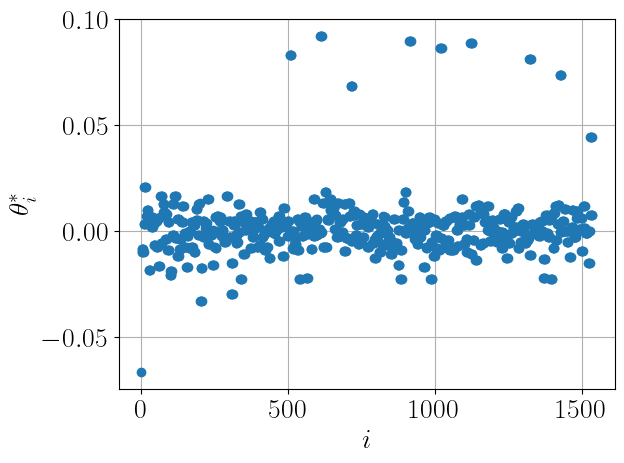

In [64]:
pars_100 = train_obs_L(labels_train_100, ansatz, L_100, method="Newton-CG")
# pars = train_obs_L(labels_train_c, ansatz, L, method="BFGS")
# pars = lstsq(A, b)[0]

s = 0
f = n_pars
plt.scatter(arange(len(pars_100))[s:f], pars_100[s:f])
plt.xlabel(r"$i$")
plt.ylabel(r"$\theta_i^*$")
plt.grid()
plt.show()


Prediction finished in 8 s
n=2 | c=4
n_train: 100 | n_test: 1000
marks: negSq
4-local_periodic_Paulies | n_pars: 1537

MSE:            0.017685492508584574
Total variance: 0.49920248404093737


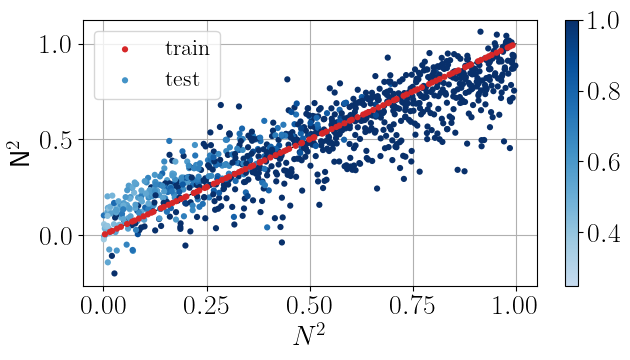

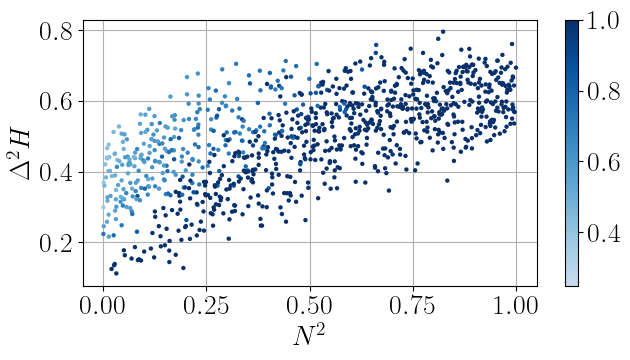

In [66]:
print()
time_start = time()
expecs_train, disps_train, H = aux_info(dms_train_100, labels_train_100, pars_100, ansatz, n_copies=n_copies)
expecs_test, disps_test, H = aux_info(dms_test, labels_test, pars_100, ansatz, n_copies=n_copies)
time_finish = time() - time_start
print("Prediction finished in %d s" %time_finish)


cmap_name = "Blues"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.25, 1., cmap.N))
cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

print("n=%d | c=%d" %(n_inp, n_copies))
print("n_train: %d | n_test: %d" %(n_train, n_test))
print("marks: %s" %marks)
print("%s | n_pars: %d" %(ansatz_info, n_pars))
# print(" n_pars: %d" %(n_pars))
print()
print("MSE:           ", sum((expecs_test - labels_test)**2)/n_test)
print("Total variance:", sum(disps_test)/n_test)

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_train_100, expecs_train, color="tab:red", s=20, edgecolor='none', zorder=4, label="train") # , color="dodgerblue"
plt.scatter(labels_test, expecs_test, c=purities_test, cmap=cmap, s=20, edgecolor='none', zorder=3, label="test") # , color="dodgerblue"
plt.plot(linspace(0, 1), linspace(0, 1), linestyle="-", linewidth=0.8, color="black")
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\mathsf{N}^2$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
plt.legend(fontsize=16,loc='upper left')
# plt.savefig(path + file_name + add_info + "-est.pdf", transparent=True, bbox_inches='tight')
save_plot="qubits_Pauli_mixedTrain_100_MSE.pdf"
plt.savefig(save_plot, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
# plt.scatter(labels_train_c, disps_train, color="tab:red", s=30, edgecolor='none', zorder=2, label="train")
plt.scatter(labels_test, disps_test, c=purities_test, cmap=cmap, s=10, edgecolor='none', zorder=2, label="test")
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\Delta^2 H$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
# plt.legend()
# plt.savefig(path + file_name + add_info + "-var.pdf", transparent=True, bbox_inches='tight')
save_plot="qubits_Pauli_mixedTrain_100_VAR.pdf"
plt.savefig(save_plot, bbox_inches='tight')
plt.show()